# Options Pricing & the Implied Volatility Surface

**Narrative:** pricing agreement (three methods) -> a real option chain -> the implied-volatility
smile/skew -> delta hedging.

This notebook ties together the six modules in `src/`. It reads the saved SPY snapshot in
`data/option_chain.csv`, so it runs end-to-end **without a network call**. Re-run
`python src/fetch_data.py` to refresh the market data.

The intellectual spine:
1. **Three pricers that agree** are a correctness proof — closed-form, lattice, and random-sampling
   errors are unrelated, so agreement is strong evidence none is wrong.
2. **The smile is the evidence Black-Scholes is wrong** — the market corrects BS's flat-vol /
   normal-returns assumption. We do not claim BS predicts the prices.
3. **The BS price is the cost of replication**, not a forecast — shown by delta hedging.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make src/ importable.
SRC = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from black_scholes import bs_price, delta, gamma, vega, theta, rho, put_call_parity_check
from binomial_tree import crr_price
from monte_carlo import mc_price
from implied_vol import implied_vol
import vol_surface as vs
from delta_hedging import simulate_delta_hedge

plt.rcParams["figure.figsize"] = (9, 5)
np.set_printoptions(suppress=True)
print("modules imported OK")

modules imported OK


## 1. Black-Scholes prices & Greeks

A textbook setup: spot 100, strike 100, 1 year, 5% rate, 20% vol, no dividend. The ATM call
should be ~10.45 (Hull). Greeks carry their full derivations in `src/black_scholes.py`.

In [2]:
S, K, T, r, sigma, q = 100.0, 100.0, 1.0, 0.05, 0.20, 0.0

call = bs_price(S, K, T, r, sigma, "call", q)
put  = bs_price(S, K, T, r, sigma, "put",  q)
print(f"Call = {call:.4f}   Put = {put:.4f}")

greeks = pd.DataFrame({
    "call": [delta(S,K,T,r,sigma,'call',q), gamma(S,K,T,r,sigma,q), vega(S,K,T,r,sigma,q),
             theta(S,K,T,r,sigma,'call',q), rho(S,K,T,r,sigma,'call',q)],
    "put":  [delta(S,K,T,r,sigma,'put',q),  gamma(S,K,T,r,sigma,q), vega(S,K,T,r,sigma,q),
             theta(S,K,T,r,sigma,'put',q),  rho(S,K,T,r,sigma,'put',q)],
}, index=["delta","gamma","vega","theta","rho"])
display(greeks.round(4))

ok, lhs, rhs, err = put_call_parity_check(S, K, T, r, sigma, q)
print(f"\nPut-call parity  C-P={lhs:.6f}  S e^-qT - K e^-rT={rhs:.6f}  |err|={err:.2e}  -> {'PASS' if ok else 'FAIL'}")

Call = 10.4506   Put = 5.5735


,call,put
delta,0.6368,-0.3632
gamma,0.0188,0.0188
vega,37.5240,37.5240
theta,-6.4140,-1.6579
rho,53.2325,-41.8905



Put-call parity  C-P=4.877058  S e^-qT - K e^-rT=4.877058  |err|=0.00e+00  -> PASS


**Why gamma is highest ATM:** gamma measures how fast delta changes with spot. At-the-money the
option is most uncertain about finishing in- or out-of-the-money, so its delta is most sensitive to
spot. Deep ITM/OTM the delta is pinned near 1 or 0 and barely moves -> gamma ~ 0.

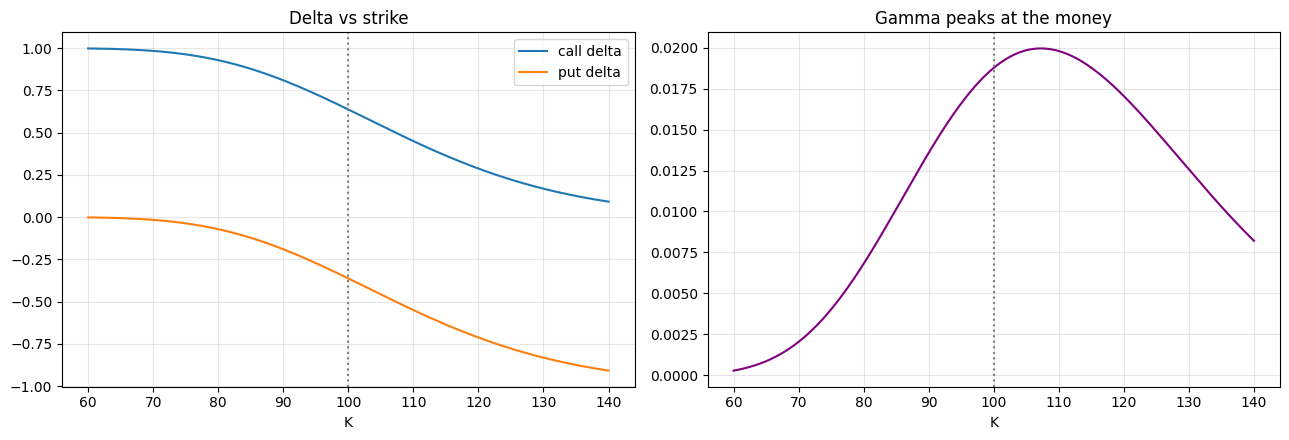

In [3]:
# Greeks across strikes: delta is a smooth S-curve, gamma peaks at the money.
Ks = np.linspace(60, 140, 200)
fig, (axd, axg) = plt.subplots(1, 2, figsize=(13, 4.5))
axd.plot(Ks, [delta(S,k,T,r,sigma,'call',q) for k in Ks], label="call delta")
axd.plot(Ks, [delta(S,k,T,r,sigma,'put', q) for k in Ks], label="put delta")
axd.axvline(S, color="gray", ls=":"); axd.set_title("Delta vs strike"); axd.set_xlabel("K"); axd.legend(); axd.grid(alpha=.3)
axg.plot(Ks, [gamma(S,k,T,r,sigma,q) for k in Ks], color="purple")
axg.axvline(S, color="gray", ls=":"); axg.set_title("Gamma peaks at the money"); axg.set_xlabel("K"); axg.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Three pricers that agree — the correctness proof

Black-Scholes (closed form), the Cox-Ross-Rubinstein binomial **tree** (lattice), and **Monte
Carlo** (random sampling) make *different* approximations. If all three land on the same price,
it is very unlikely they are all wrong in the same way. This is the project's core unit test.

In [4]:
rows = []
for ot in ("call", "put"):
    bs = bs_price(S, K, T, r, sigma, ot, q)
    tr_ = crr_price(S, K, T, r, sigma, ot, q, N=2000)
    mc = mc_price(S, K, T, r, sigma, ot, q, n_paths=1_000_000, antithetic=True, seed=7)
    rows.append([ot, bs, tr_, mc["price"], f"[{mc['ci95'][0]:.4f}, {mc['ci95'][1]:.4f}]",
                 "OK" if mc['ci95'][0] <= bs <= mc['ci95'][1] else "OUT"])
display(pd.DataFrame(rows, columns=["type","Black-Scholes","CRR tree","Monte Carlo","MC 95% CI","BS in CI?"]).round(5))

,type,Black-Scholes,CRR tree,Monte Carlo,MC 95% CI,BS in CI?
0,call,10.45058,10.44958,10.43647,"[10.4161, 10.4568]",OK
1,put,5.57353,5.57253,5.56450,"[5.5515, 5.5775]",OK


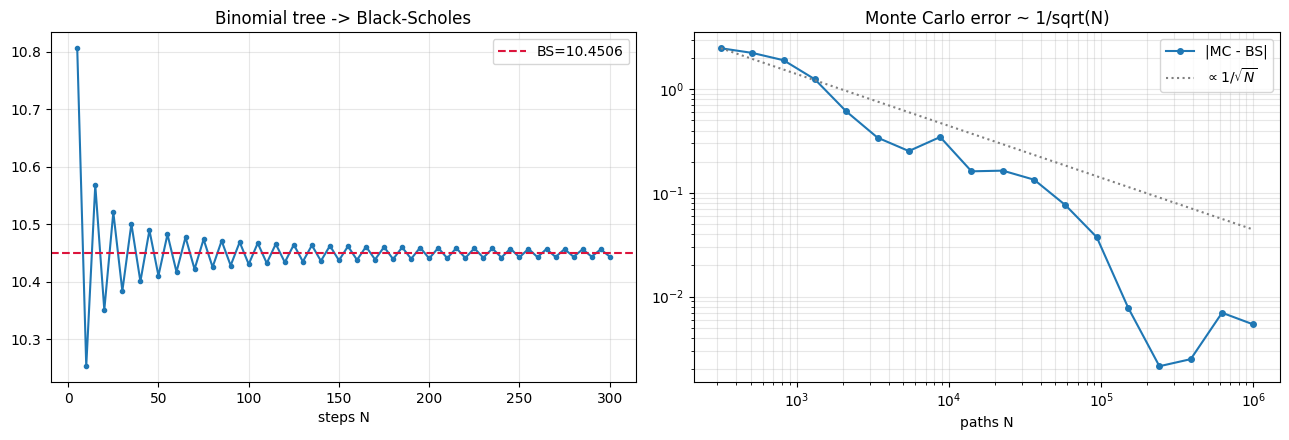

In [5]:
# Tree -> BS convergence (note the odd/even sawtooth) and MC error ~ 1/sqrt(N).
bs_call = bs_price(S, K, T, r, sigma, "call", q)
Ns = np.arange(5, 305, 5)
tree_px = [crr_price(S, K, T, r, sigma, "call", q, N=int(n)) for n in Ns]

mc_Ns = np.unique(np.logspace(2.5, 6, 18).astype(int))
mc_err = [abs(mc_price(S,K,T,r,sigma,'call',q,n_paths=int(n),seed=7)["price"] - bs_call) for n in mc_Ns]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(Ns, tree_px, "o-", ms=3); a1.axhline(bs_call, color="crimson", ls="--", label=f"BS={bs_call:.4f}")
a1.set_title("Binomial tree -> Black-Scholes"); a1.set_xlabel("steps N"); a1.legend(); a1.grid(alpha=.3)
a2.loglog(mc_Ns, mc_err, "o-", ms=4, label="|MC - BS|")
a2.loglog(mc_Ns, mc_err[0]*np.sqrt(mc_Ns[0]/mc_Ns.astype(float)), ":", color="gray", label=r"$\propto 1/\sqrt{N}$")
a2.set_title("Monte Carlo error ~ 1/sqrt(N)"); a2.set_xlabel("paths N"); a2.legend(); a2.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

## 3. A real option chain — SPY

We use a real **SPY** (S&P 500 ETF) chain (NSE blocks scraping; SPY's liquidity gives a cleaner
skew — the spec's recommended fallback). Assumptions: `r = 4.3%` (US 3M T-bill), `q = 1.2%` (SPY
dividend yield), time-to-expiry in years (ACT/365).

In [6]:
raw = vs.load_chain()
print("rows:", len(raw), "| spot:", round(raw['spot'].iloc[0], 2))
print("expiries:", sorted(raw['expiry'].unique()))
print("\nT (years) per expiry:", {e: round(g['T'].iloc[0], 4) for e, g in raw.groupby('expiry')})
print("\nnull counts:\n", raw.isnull().sum().to_string())
raw.head()

rows: 1203 | spot: 757.73
expiries: ['2026-06-11', '2026-07-02', '2026-07-31', '2026-08-31']

T (years) per expiry: {'2026-06-11': np.float64(0.0193), '2026-07-02': np.float64(0.0769), '2026-07-31': np.float64(0.1563), '2026-08-31': np.float64(0.2413)}

null counts:
 expiry            0
option_type       0
strike            0
bid               0
ask               0
last              0
mid               0
volume           27
open_interest     1
spot              0
snapshot_utc      0
T                 0
moneyness         0


,expiry,option_type,strike,bid,ask,last,mid,volume,open_interest,spot,snapshot_utc,T,moneyness
0,2026-06-11,call,670.0,86.83,89.18,83.20,88.005,6.0,6.0,757.72998,2026-06-04T18:31:23+00:00,0.019347,0.884220
1,2026-06-11,call,700.0,56.92,58.98,56.64,57.950,1.0,2.0,757.72998,2026-06-04T18:31:23+00:00,0.019347,0.923812
2,2026-06-11,call,709.0,47.91,50.72,49.00,49.315,1.0,NaN,757.72998,2026-06-04T18:31:23+00:00,0.019347,0.935690
3,2026-06-11,call,710.0,46.94,49.01,46.69,47.975,1.0,2.0,757.72998,2026-06-04T18:31:23+00:00,0.019347,0.937009
4,2026-06-11,call,725.0,32.06,34.83,28.79,33.445,1.0,6.0,757.72998,2026-06-04T18:31:23+00:00,0.019347,0.956805


### Cleaning (the anti-garbage filters)

Drop options without a genuine two-sided market, below a minimum price (one tick of noise = huge
IV), outside a 0.80-1.20 moneyness band (vega ~ 0 in the deep wings), or with no open interest.
Then keep the **OTM wing** (puts below spot, calls above) — the liquid, early-exercise-clean quotes
that stitch into one continuous smile. Implied vol is backed out of the **mid** price.

In [7]:
clean = vs.clean_chain(raw)
otm   = vs.select_otm(clean)
iv_df = vs.compute_iv(otm)
display(iv_df.groupby("expiry")["iv"].describe()[["count","mean","min","max"]].round(4))

clean_chain: kept 981/1203 rows after filtering


compute_iv: 568/568 rows produced a finite IV


,count,mean,min,max
expiry,,,,
2026-06-11,69.0,0.1390,0.0866,0.2577
2026-07-02,123.0,0.1614,0.1014,0.3454
2026-07-31,189.0,0.1918,0.1149,0.3034
2026-08-31,187.0,0.1940,0.1226,0.2850


## 4. The volatility smile / skew

Equity-index options show a **downward skew**: out-of-the-money **puts** trade at *higher* implied
vol than out-of-the-money calls. The market is paying up for crash protection (a fat left tail) —
precisely the risk Black-Scholes' normal-returns assumption ignores.

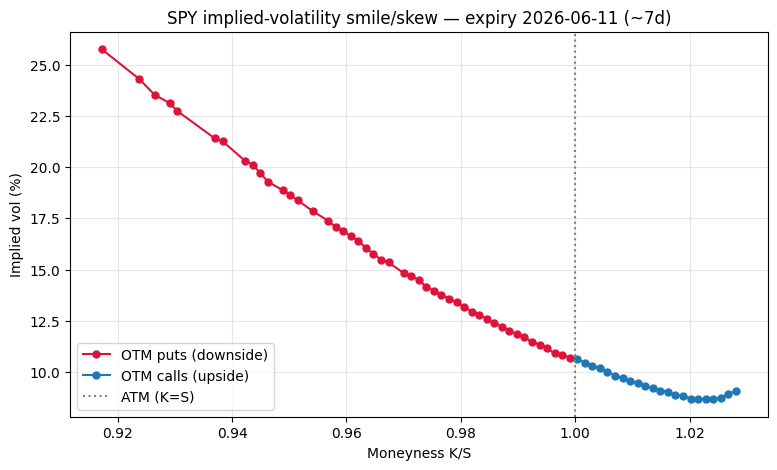

In [8]:
exp0 = sorted(iv_df["expiry"].unique())[0]
sub = iv_df[iv_df["expiry"] == exp0].sort_values("moneyness")
puts, calls = sub[sub.option_type=="put"], sub[sub.option_type=="call"]
plt.plot(puts.moneyness, puts.iv*100, "o-", color="crimson", ms=5, label="OTM puts (downside)")
plt.plot(calls.moneyness, calls.iv*100, "o-", color="#1f77b4", ms=5, label="OTM calls (upside)")
plt.axvline(1.0, color="gray", ls=":", label="ATM (K=S)")
plt.xlabel("Moneyness K/S"); plt.ylabel("Implied vol (%)")
plt.title(f"SPY implied-volatility smile/skew — expiry {exp0} (~{sub['T'].iloc[0]*365:.0f}d)")
plt.legend(); plt.grid(alpha=.3); plt.show()

### Quantifying the skew across expiries

`put_wing - call_wing` (≈ 95% vs 105% moneyness, a proxy for 25-delta) is positive at every expiry
— and **steepens at the short end**, because near-term crash risk dominates short-dated options.
The ATM term structure slopes up (calm-market contango).

In [9]:
vs.skew_report(iv_df)


=== Skew analysis (per expiry) ===
        expiry | ~days |  ATM IV | 25d-ish put | 25d-ish call | put-call skew
    2026-06-11 |     7 |  10.62% |      18.63% |        9.07% |        +9.56%
    2026-07-02 |    28 |  12.27% |      17.76% |       10.16% |        +7.60%
    2026-07-31 |    57 |  13.97% |      18.02% |       11.90% |        +6.11%
    2026-08-31 |    88 |  15.15% |      18.22% |       13.12% |        +5.11%

  Positive put-minus-call skew => OTM puts richer than OTM calls
  => market pays up for crash protection (downward / negative skew).


### The 3D implied-volatility surface

Strike (moneyness) x time-to-expiry x IV. You can see both the skew (along moneyness) and the term
structure (along days).

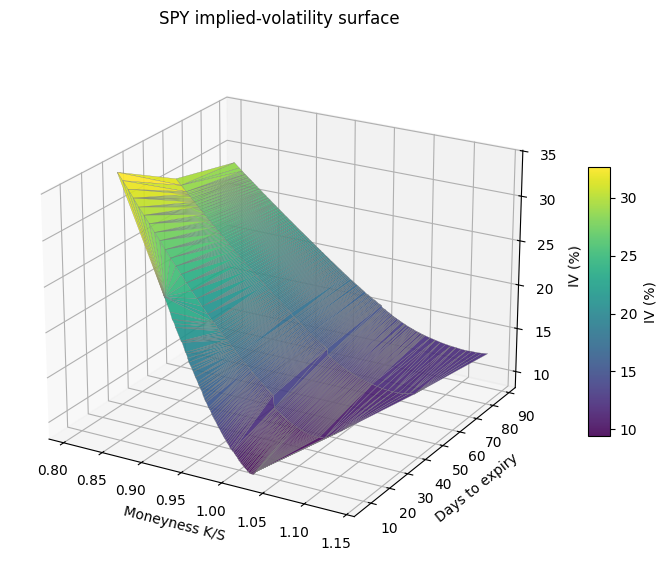

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
days = iv_df["T"].values * 365.0
fig = plt.figure(figsize=(10, 7)); ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_trisurf(iv_df["moneyness"].values, days, iv_df["iv"].values * 100,
                       cmap=cm.viridis, edgecolor="gray", linewidth=0.2, alpha=0.9)
ax.set_xlabel("Moneyness K/S"); ax.set_ylabel("Days to expiry"); ax.set_zlabel("IV (%)")
ax.set_title("SPY implied-volatility surface"); ax.view_init(elev=22, azim=-60)
fig.colorbar(surf, shrink=.5, aspect=12, label="IV (%)"); plt.show()

## 5. Delta hedging — the BS price is the cost of replication

Sell one ATM call at its BS price, then hold `delta` shares and rebalance along a simulated GBM
path. The **hedging error** is the final P&L of (short option + stock hedge + cash). Two results:

- **Mean error ≈ 0 even though the path drift `mu=0.10` ≠ `r=0.05`** — replication is
  drift-independent. You do not need to predict the market to hedge.
- **The error std shrinks as 1/√n** with rebalancing frequency (Boyle-Emanuel) — recovering the
  continuous-hedging ideal behind Black-Scholes.

In [11]:
freqs = [1, 2, 5, 10, 21, 50, 100, 252]
prem = bs_price(100, 100, 1, 0.05, 0.20, "call", 0)
errs = {n: simulate_delta_hedge(100,100,1,0.05,0.20,"call",0,n_rebalance=n,n_paths=40000,mu=0.10,seed=7) for n in freqs}
summary = pd.DataFrame({"n_rebalance":freqs,
                        "mean_err":[errs[n].mean() for n in freqs],
                        "std_err":[errs[n].std() for n in freqs],
                        "std*sqrt(n)":[errs[n].std()*np.sqrt(n) for n in freqs]})
display(summary.round(4))
print(f"premium received = {prem:.4f};  mean error ~ 0 confirms drift-independent replication")

,n_rebalance,mean_err,std_err,std*sqrt(n)
0,1,-0.1884,6.1223,6.1223
1,2,-0.1078,4.4198,6.2506
2,5,-0.0360,2.8652,6.4068
3,10,-0.0021,2.0613,6.5185
4,21,-0.0174,1.4537,6.6615
5,50,-0.0049,0.9436,6.6720
6,100,-0.0054,0.6819,6.8188
7,252,0.0018,0.4255,6.7544


premium received = 10.4506;  mean error ~ 0 confirms drift-independent replication


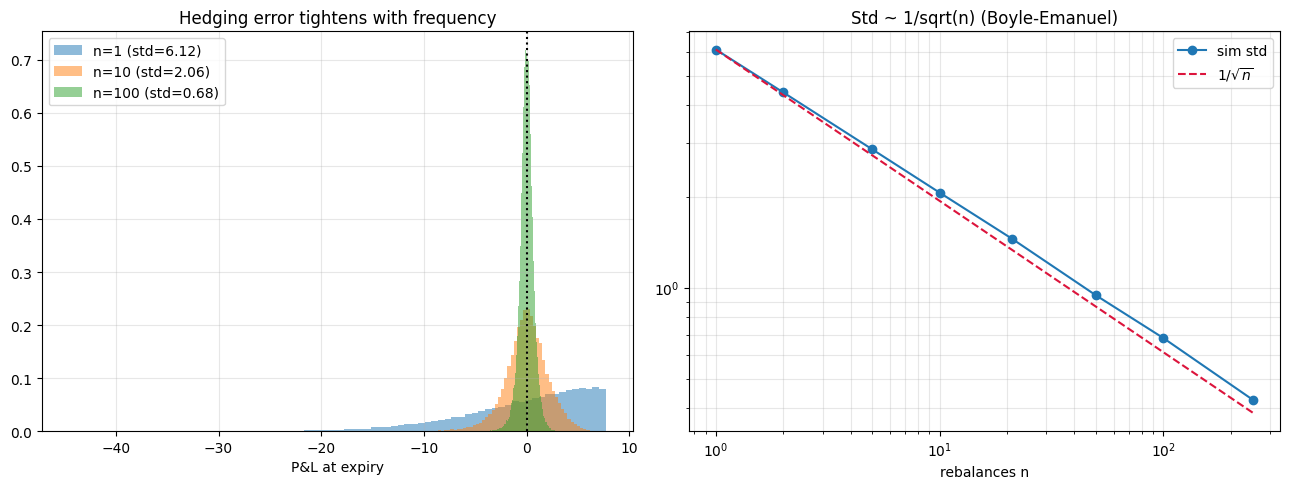

In [12]:
fig, (h, s) = plt.subplots(1, 2, figsize=(13, 5))
for n in [1, 10, 100]:
    h.hist(errs[n], bins=80, density=True, alpha=.5, label=f"n={n} (std={errs[n].std():.2f})")
h.axvline(0, color="k", ls=":"); h.set_title("Hedging error tightens with frequency")
h.set_xlabel("P&L at expiry"); h.legend(); h.grid(alpha=.3)
fa = np.array(freqs, float); sd = np.array([errs[n].std() for n in freqs])
s.loglog(fa, sd, "o-", label="sim std"); s.loglog(fa, sd[0]*np.sqrt(fa[0]/fa), "--", color="crimson", label=r"$1/\sqrt{n}$")
s.set_title("Std ~ 1/sqrt(n) (Boyle-Emanuel)"); s.set_xlabel("rebalances n"); s.legend(); s.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

### Transaction costs — the real-world tension

With a 5 bps cost per trade, mean P&L turns **negative and worsens with more rebalancing**: cutting
discretization variance costs more in trading. The optimal frequency trades these off.

In [13]:
tc_rows = []
for n in [5, 21, 100, 252]:
    e = simulate_delta_hedge(100,100,1,0.05,0.20,"call",0,n_rebalance=n,n_paths=40000,mu=0.10,tc=0.0005,seed=7)
    tc_rows.append([n, e.mean(), e.std()])
display(pd.DataFrame(tc_rows, columns=["n_rebalance","mean_err (5bps)","std_err"]).round(4))

,n_rebalance,mean_err (5bps),std_err
0,5,-0.1380,2.8733
1,21,-0.1592,1.4608
2,100,-0.2314,0.6903
3,252,-0.3142,0.4397


## Conclusions

- **Three independent pricers agree** to within Monte-Carlo error — the correctness proof.
- A **real SPY chain** shows the textbook **downward equity skew** that steepens at short maturities
  and an upward-sloping vol term structure. The smile is the market correcting Black-Scholes'
  flat-vol assumption — not BS predicting prices.
- **Delta hedging** reproduces the replication result: mean error ≈ 0 regardless of drift, error
  std ~ 1/√n, and transaction costs impose a real frequency tradeoff.

**Interview one-liners:** *Why is gamma highest ATM?* (delta most sensitive there). *Why does the
skew exist?* (crash-risk / fat-left-tail pricing). *Why can't you solve BS for sigma in closed
form?* (sigma sits inside N(d1), N(d2)). *What is the BS price the price of?* (the replicating
portfolio). *Three methods agree — how do you know they aren't all wrong the same way?* (unrelated
error sources).